In [1]:
# Veriyi oku ve döndür
import pandas as pd
def load_data(path):
    return pd.read_csv(path)

In [2]:
def clean_data(df):
    df["TotalCharges"]= df["TotalCharges"].replace(" ", pd.NA) # boşlukları NaN yapıyoruz
    df.dropna(subset=["TotalCharges"], inplace=True) # TotalCharges sütunundaki NaN verileri temizle ve orjinal df'e uygula (inplace=True parametresi ile) 
    df["TotalCharges"]=df["TotalCharges"].astype(float) # 
    df.drop(columns="customerID",inplace=True) # customerID sütununu veri setinden çıkar.
    return df

Accuracy Score: 0.681592039800995 
Classification Report:               precision    recall  f1-score   support

           0       0.91      0.62      0.74      1033
           1       0.45      0.84      0.58       374

    accuracy                           0.68      1407
   macro avg       0.68      0.73      0.66      1407
weighted avg       0.79      0.68      0.70      1407
 
Confusion Matrix: [[645 388]
 [ 60 314]] 


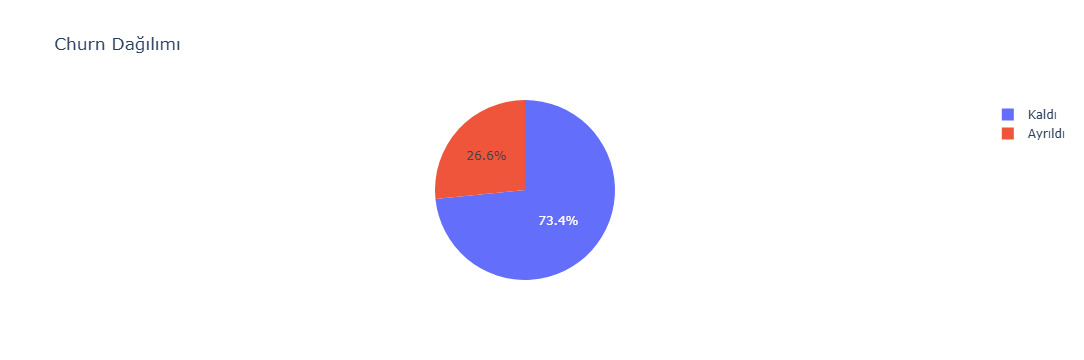

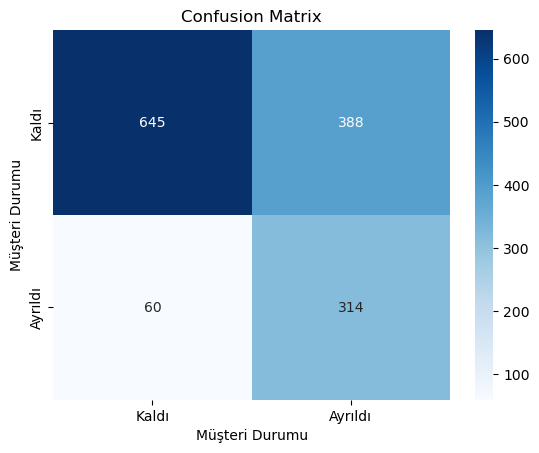

En iyi parametreler: {'model__var_smoothing': 1e-09}
En iyi CV skoru: 0.6963555555555556
Accuracy Score: 0.681592039800995 
Classification Report:               precision    recall  f1-score   support

           0       0.91      0.62      0.74      1033
           1       0.45      0.84      0.58       374

    accuracy                           0.68      1407
   macro avg       0.68      0.73      0.66      1407
weighted avg       0.79      0.68      0.70      1407
 
Confusion Matrix: [[645 388]
 [ 60 314]] 
Binary: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
Categoric: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
(7032, 42)
gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64

In [20]:
if __name__=="__main__": #  bu dosya direkt çalıştırıldığında içindeki kod çalışır. Başka bir dosya bu dosyayı import ettiğinde çalışmaz. 
    df=load_data("dataset.csv")
    df=clean_data(df)
    binary_cols, categoric_cols=find_column_types(df)
    df=encode_data(df, binary_cols, categoric_cols)
    X_train, X_test, y_train, y_test=split_data(df)
    model=build_model(X_train, y_train)
    y_pred=evaluate_model(model, X_test, y_test)
    visualize_results(df,y_test, y_pred)
    best_model=optimize_model(X_train, y_train)
    y_pred_optimized=evaluate_model(best_model, X_test, y_test)
    print("Binary:", binary_cols)
    print("Categoric:", categoric_cols)
    print(df.shape)
    print(df.dtypes)
    print(X_train.shape, X_test.shape)

In [4]:
for col in df.select_dtypes(include='object').columns: # sadece object türündeki columnları seç ve her birinin ismini ve içindeki birbirinden farklı kaç değer olduğunu yazdır.
    print(col, df[col].unique())

gender ['Female' 'Male']
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn ['No' 'Yes']


In [5]:
def find_column_types(df):
    binary_cols=[]
    categoric_cols=[]
    for col in df.select_dtypes(include='object').columns: # df deki bütun sütunları (object dtype dahil) al.
        if df[col].nunique()==2: # aldığın her sütundaki benzersiz değerler 2 ye eşitse binary listesine ekle değilse categoric listesine ekle
            binary_cols.append(col)
        else:
            categoric_cols.append(col)
    return binary_cols, categoric_cols       

In [6]:
from sklearn.preprocessing import LabelEncoder
# Encoding fonksiyonu
def encode_data(df, binary_cols, categoric_cols):
    binary_cols=[col for col in binary_cols if col!="Churn"]
    le=LabelEncoder()
    for col in binary_cols:
        df[col]=le.fit_transform(df[col])
    df["Churn"]=df["Churn"].map({"No":0, "Yes":1})
    df=pd.get_dummies(df, columns=categoric_cols, dtype=int) # contract sütunundaki unique değerler 3 tane 3 farklı sütun oluyor orda ilgili satır hangisi ise 1 kalanlarına 0 veriyor
    return df

In [7]:
from sklearn.model_selection import train_test_split
def split_data(df):
    X=df.drop(columns="Churn") # X'i ayır
    y=df["Churn"] # y'yi ayır 
    X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)# train_test_split uygula
    return X_train, X_test, y_train, y_test # X_train, X_test, y_train, y_test döndür

In [8]:
from sklearn.naive_bayes import GaussianNB
def build_model(X_train, y_train):
    my_model=GaussianNB() # Modeli oluştur
    my_model.fit(X_train, y_train) # Modeli Eğit
    return my_model

In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
def evaluate_model(model, X_test, y_test):
    my_pred=model.predict(X_test)
    print(f"Accuracy Score: {accuracy_score(y_test, my_pred)} ")
    print(f"Classification Report: {classification_report(y_test, my_pred)} ")
    print(f"Confusion Matrix: {confusion_matrix(y_test, my_pred)} ")
    return my_pred

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
def visualize_results(df,y_test, y_pred):
    df["Churn_label"]=df["Churn"].map({0:"Kaldı", 1:"Ayrıldı"})
    fig=px.pie(df, names="Churn_label", title="Churn Dağılımı")
    fig.show()
    sns.heatmap(
        confusion_matrix(y_test, y_pred),
        annot=True, # sayıları göster
        fmt="d", # tam sayı formatı
        cmap="Blues", # renk
        xticklabels=["Kaldı","Ayrıldı"],
        yticklabels=["Kaldı","Ayrıldı"]
    )# Confusion Matrix heatmap - seaborn
    plt.title("Confusion Matrix")
    plt.xlabel("Müşteri Durumu")
    plt.ylabel("Müşteri Durumu")
    plt.show()

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
def optimize_model(X_train, y_train):
    pipeline=Pipeline([
        ("scaler", StandardScaler()),
        ("model", GaussianNB())
    ])
    params={
        'model__var_smoothing':[1e-9, 1e-7, 1e-5, 1e-3, 1e-1]
    }
    g_search=GridSearchCV(pipeline,cv=5,param_grid=params)
    g_search.fit(X_train, y_train)
    print(f"En iyi parametreler: {g_search.best_params_}")
    print(f"En iyi CV skoru: {g_search.best_score_}")
    return g_search.best_estimator_